IMPORT LIBRARIES

In [4]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.figure_factory as ff
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb
import joblib
import shap

In [5]:
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

LOAD DATA

In [6]:

df = pd.read_csv("energydata_complete.csv")

print("Head of the dataframe:")
display(df.head())

print("\nDataframe Info:")
df.info()

print(f"\nDuplicated rows: {df.duplicated().sum()}")
print("\nDescriptive Statistics:")
display(df.describe())

Head of the dataframe:


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,11-01-2016 17:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,11-01-2016 17:10,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,11-01-2016 17:20,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,11-01-2016 17:30,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390
4,11-01-2016 17:40,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097



Dataframe Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.412580,755.522602,79.750418,4.039752,38.330834,3.760995,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.318464,7.399441,14.901088,2.451221,11.794719,4.195248,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.670000,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.920000,756.100000,83.666667,3.666667,40.000000,3.430000,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.400000,760.933333,91.666667,5.500000,40.000000,6.570000,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


3.Exploratory data analysis

In [7]:
# Distribution of Appliances usage
fig_hist = px.histogram(df, x="Appliances", nbins=50, title="Appliances Energy Distribution")
fig_hist.show()

# Correlation Heatmap
corr = df.select_dtypes(np.number).corr()
fig_heat = ff.create_annotated_heatmap(
    z=corr.values,
    x=corr.columns.tolist(),
    y=corr.index.tolist(),
    colorscale="Viridis"
)
fig_heat.update_layout(title="Correlation Heatmap")
fig_heat.show()

In [8]:
df.columns = df.columns.str.strip()

4.Feature engineering

In [9]:
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], format="%d-%m-%Y %H:%M")
    df['hour'] = df['date'].dt.hour
    df['day'] = df['date'].dt.day
    df['weekday'] = df['date'].dt.weekday
    df['is_weekend'] = (df['weekday'] >= 5).astype(int)

# Drop original date column after extraction
    df.drop(columns=['date'], inplace=True)

Visualizing Relationships

In [10]:
# Scatter: Temperature vs Appliances
fig_scatter = px.scatter(df, x="T1", y="Appliances", trendline="ols",
                         title="Kitchen Temperature vs Appliances Usage")
fig_scatter.show()

# Boxplot by Hour
fig_box = px.box(df, x="hour", y="Appliances",
                 title="Appliances Usage by Hour of Day")
fig_box.show()

Outlier Handling

In [11]:
numeric_cols = df.select_dtypes(np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

Model Training and Evaluation

In [12]:
# Split data
X = df.drop("Appliances", axis=1)
y = df["Appliances"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessors
num_features = X.columns.tolist()
linear_preprocessor = ColumnTransformer([('num', StandardScaler(), num_features)])
tree_preprocessor = ColumnTransformer([('num', 'passthrough', num_features)])

# Model Dictionary
models = {
    "Linear Regression": Pipeline([('prep', linear_preprocessor), ('model', LinearRegression())]),
    "Random Forest": Pipeline([('prep', tree_preprocessor), ('model', RandomForestRegressor(n_estimators=300, random_state=42))]),
    "XGBoost": Pipeline([('prep', tree_preprocessor), ('model', xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42))]),
    "LightGBM": Pipeline([('prep', tree_preprocessor), ('model', lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42))]),
    "CatBoost": Pipeline([('prep', tree_preprocessor), ('model', CatBoostRegressor(iterations=600, learning_rate=0.05, depth=8, verbose=False, random_state=42))])
}

# Evaluation function
def evaluate(model, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"\n{name} Results:")
    print(f"MAE : {mean_absolute_error(y_test, pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.2f}")
    print(f"R2  : {r2_score(y_test, pred):.2f}")

for name, model in models.items():
    evaluate(model, name)


Linear Regression Results:
MAE : 27.08
RMSE: 36.44
R2  : 0.28

Random Forest Results:
MAE : 14.23
RMSE: 21.51
R2  : 0.75

XGBoost Results:
MAE : 16.89
RMSE: 24.51
R2  : 0.67
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000779 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6336
[LightGBM] [Info] Number of data points in the train set: 15788, number of used features: 30
[LightGBM] [Info] Start training from score 78.947935

LightGBM Results:
MAE : 16.35
RMSE: 23.95
R2  : 0.69

CatBoost Results:
MAE : 16.99
RMSE: 24.72
R2  : 0.67


Hyperparameter Tuning and Explainability

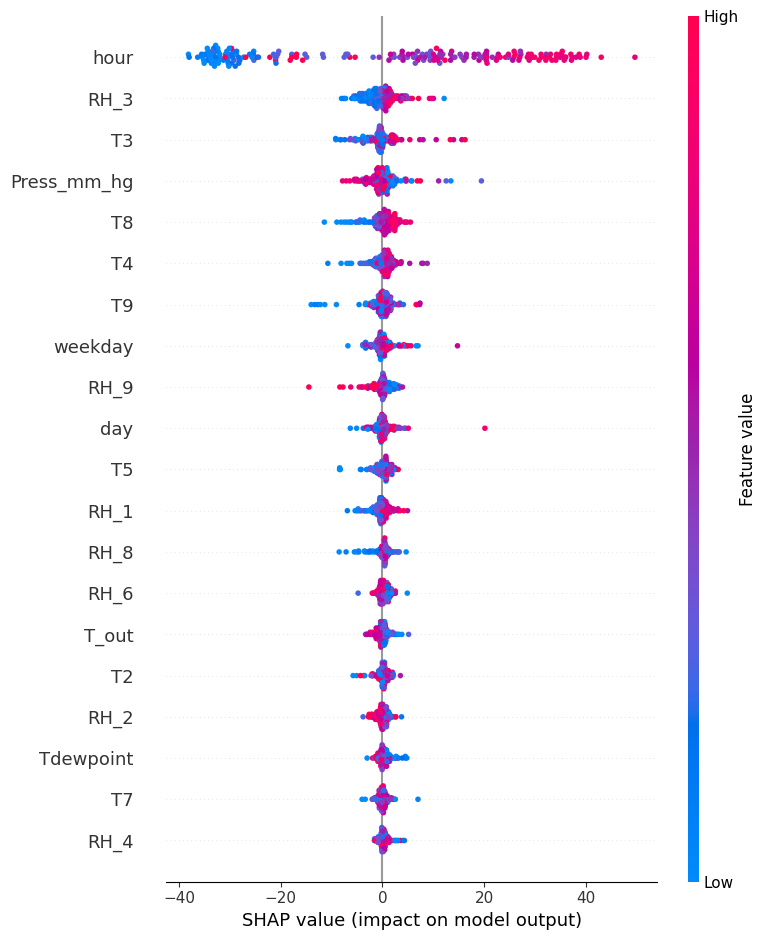

['best_energy_model.pkl']

In [14]:
# Grid Search for Random Forest
rf_params = {'model__n_estimators': [200, 300], 'model__max_depth': [10, 20, None]}
rf_grid = GridSearchCV(models["Random Forest"], rf_params, cv=3, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train)

# SHAP Explainability
explainer = shap.TreeExplainer(rf_grid.best_estimator_.named_steps['model'])
shap_values = explainer.shap_values(X_test.sample(200, random_state=42))
shap.summary_plot(shap_values, X_test.sample(200, random_state=42))

# Save the best model
joblib.dump(rf_grid.best_estimator_, "best_energy_model.pkl")